In this notebook, we will train a classifier on the latent representation produced using the Imputation model (variational autoencoder) for cell type prediction. This is just a demo to see how the classifier will perform on this data

In [2]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from cellarium.ml.data.fileio import read_h5ad_file

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [3]:
def train_classifiers(X_train, y_train):
    """Train multiple classifier models on the provided training data."""

    # Multinomial Logistic Regression -- this is considered to be a strong baseline model for cell type classification 
    print("Training Logistic Regression model...") 
    lr_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
    lr_model.fit(X_train, y_train)

    # Random Forest Classifier
    print("Training Random Forest model...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Support Vector Machine Classifier
    print("Training SVM model...")
    svm_model = SVC(gamma='auto', random_state=42)
    svm_model.fit(X_train, y_train)

    return lr_model, rf_model, svm_model

In [4]:
def evaluate_classifiers(models, X_test, y_test, prob, noise2self_ratio):
    """Evaluate the trained classifiers on the test data and print classification reports."""
    
    model_names = ["Logistic Regression", "Random Forest", "SVM"]
    metrics_df = []
    for model, name in zip(models, model_names):
        print(f"\nEvaluating {name} model for masking probability {prob}...")
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # --- Extract per-class metrics ---
        for cell_type, stats in report.items():
            if cell_type in ["accuracy", "macro avg", "weighted avg"]:
                continue

            metrics_df.append({
                "classifier": name,
                "masking_prob": prob,
                "noise2self_ratio": noise2self_ratio,
                "cell_type": cell_type,
                "precision": stats["precision"],
                "recall": stats["recall"],
                "f1_score": stats["f1-score"],
            })

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        fig, ax = plt.subplots(figsize=(12, 10))
        disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
        plt.title(f"{name} Confusion Matrix (Masking Probability: {prob})")
        plt.tight_layout()
        plt.show()
    return pd.DataFrame(metrics_df)


Training Logistic Regression model...


/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Random Forest model...
Training SVM model...

Evaluating Logistic Regression model for masking probability 0.5...


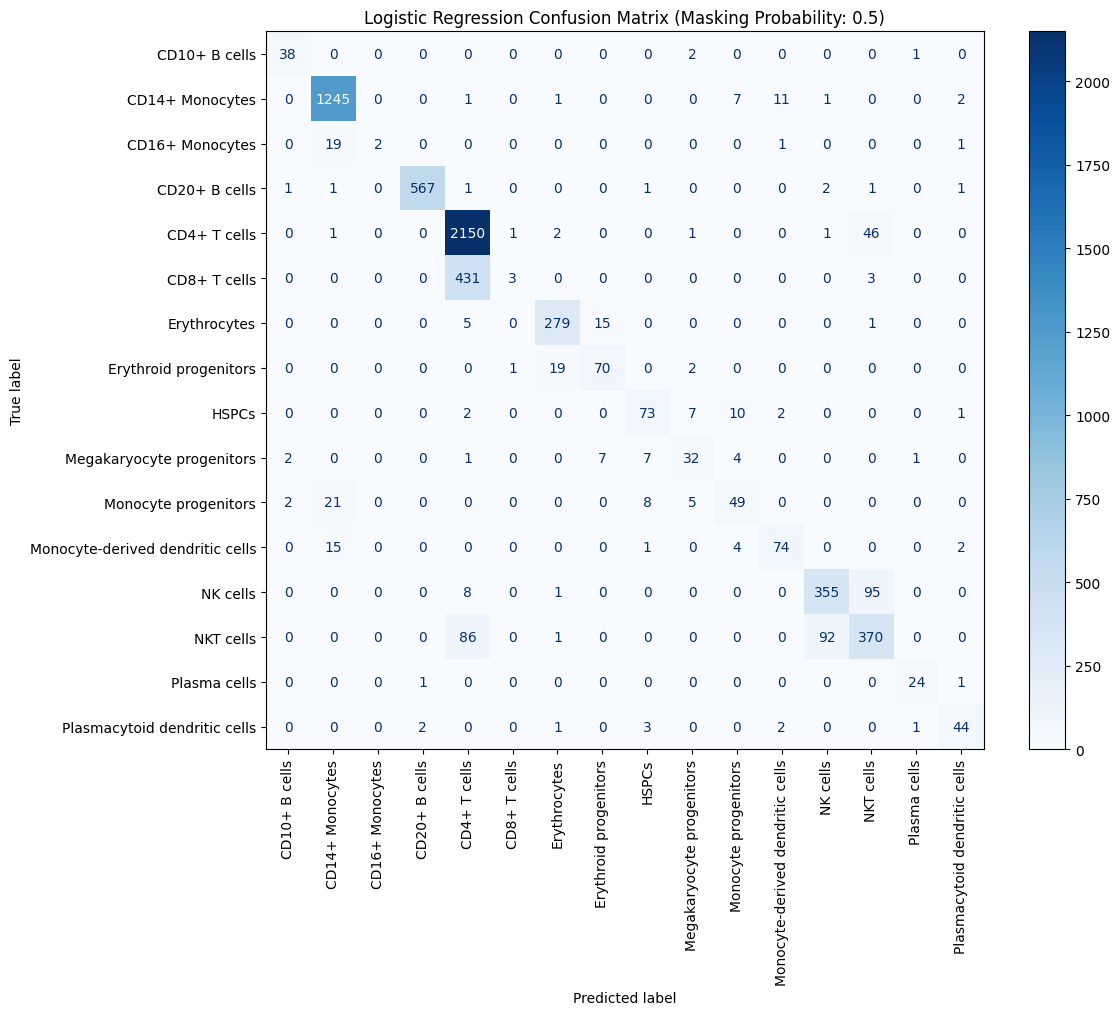


Evaluating Random Forest model for masking probability 0.5...


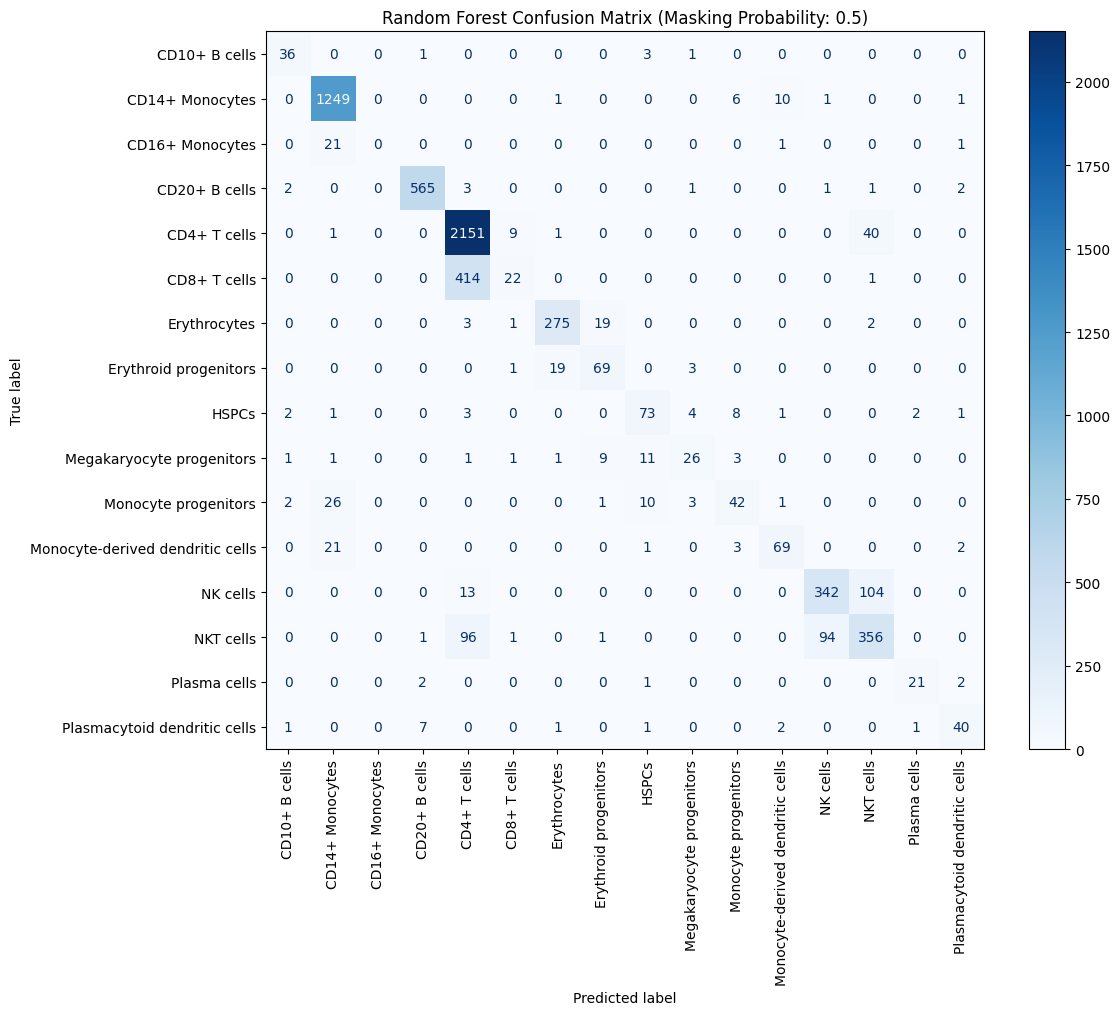


Evaluating SVM model for masking probability 0.5...


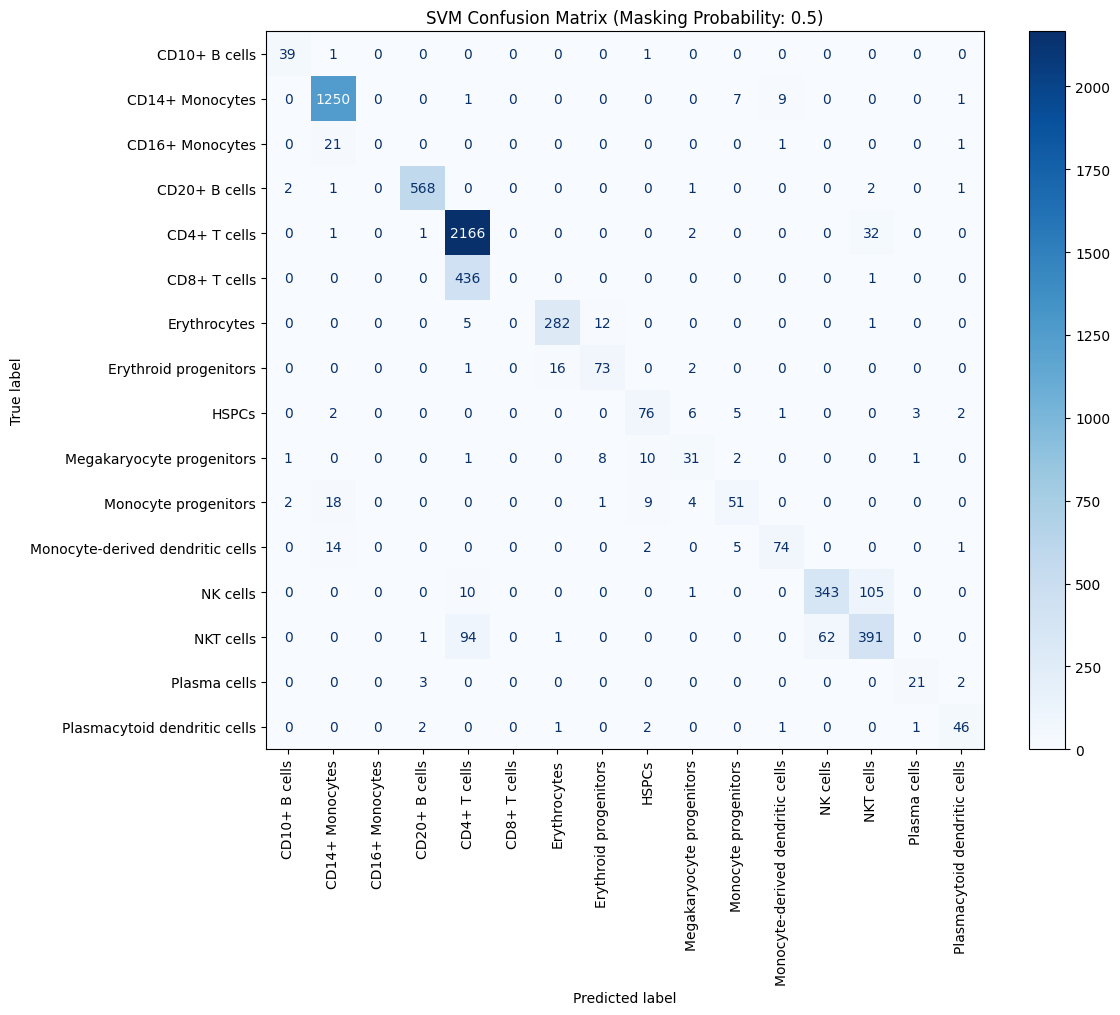

In [5]:

# two conditions here is the case where annealing is used and the other with scvi dropout only (no annealing)
adata_anneal = read_h5ad_file(f"runs/imputation_annealing/mask_50/imputation.h5ad")
with open(f"runs/imputation_annealing/mask_50/predictions.pkl", "rb") as f:
                predictions_anneal = pickle.load(f)


# Extract features (latent representation) and labels
X = predictions_anneal[f"mask50_latent_masked"]
y = adata_anneal.obs["final_annotation"]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the classifiers
lr_model, rf_model, svm_model = train_classifiers(X_train=X_train, y_train=y_train)
        
# Evaluate the classifiers
metrics_df = evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=0.5, noise2self_ratio=0)


Training Logistic Regression model...


/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Random Forest model...
Training SVM model...

Evaluating Logistic Regression model for masking probability 0.5...


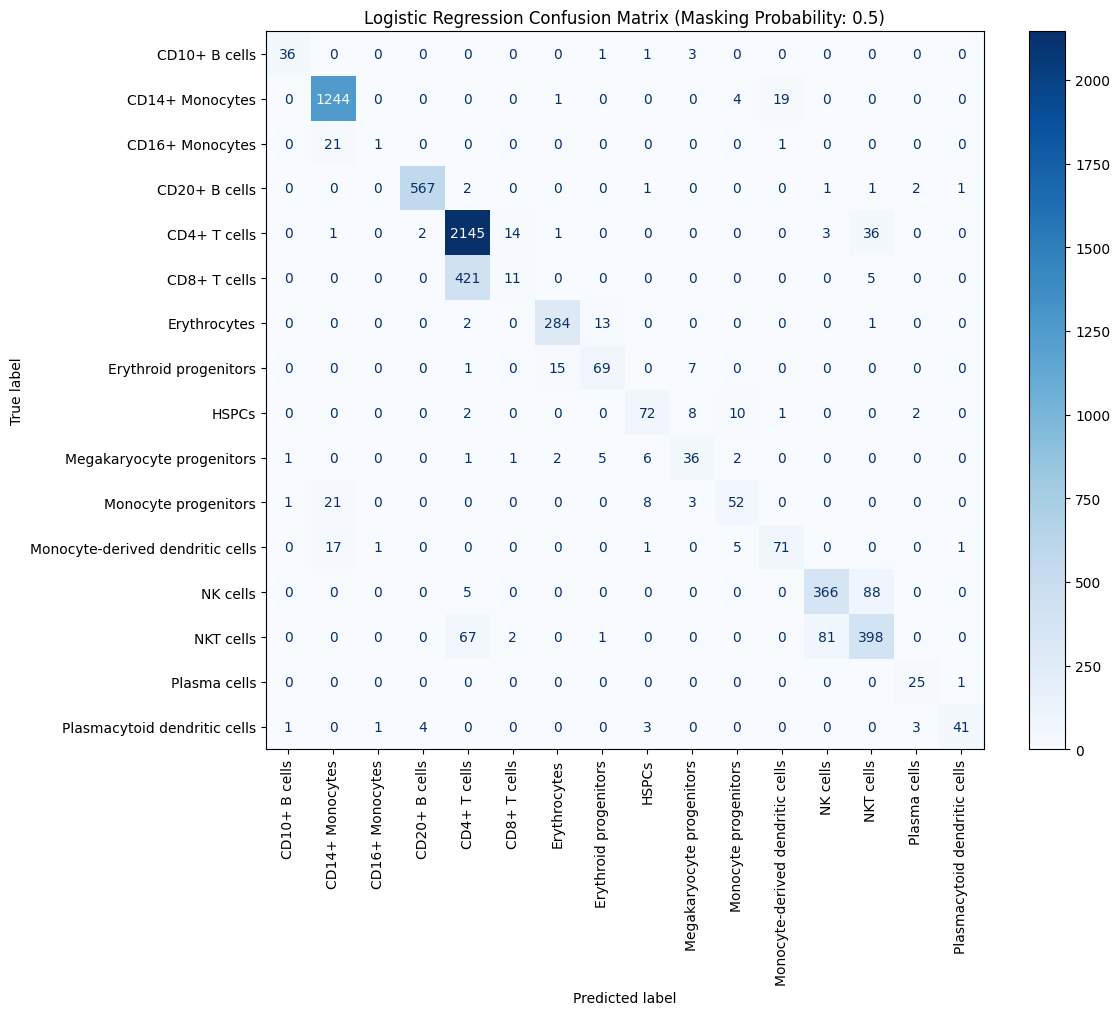


Evaluating Random Forest model for masking probability 0.5...


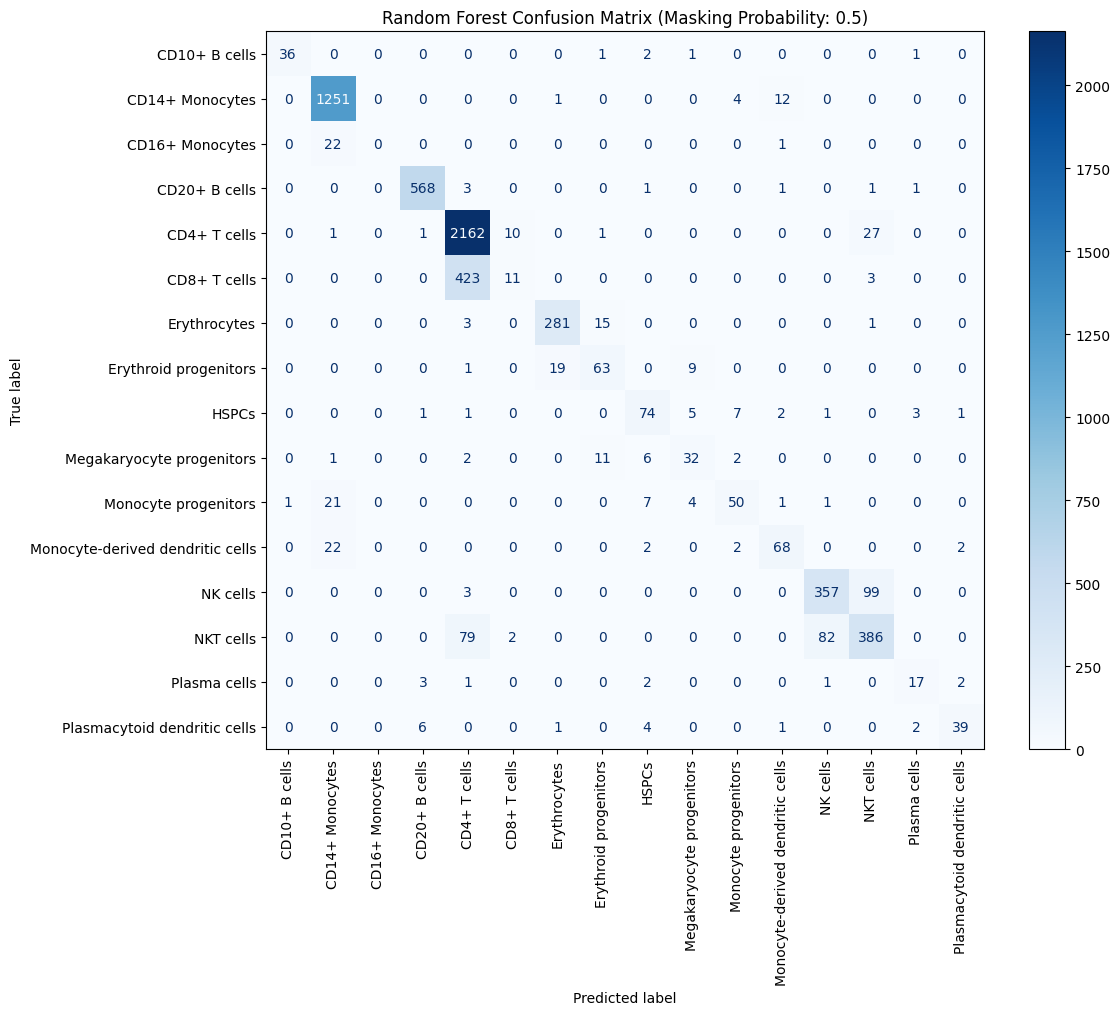


Evaluating SVM model for masking probability 0.5...


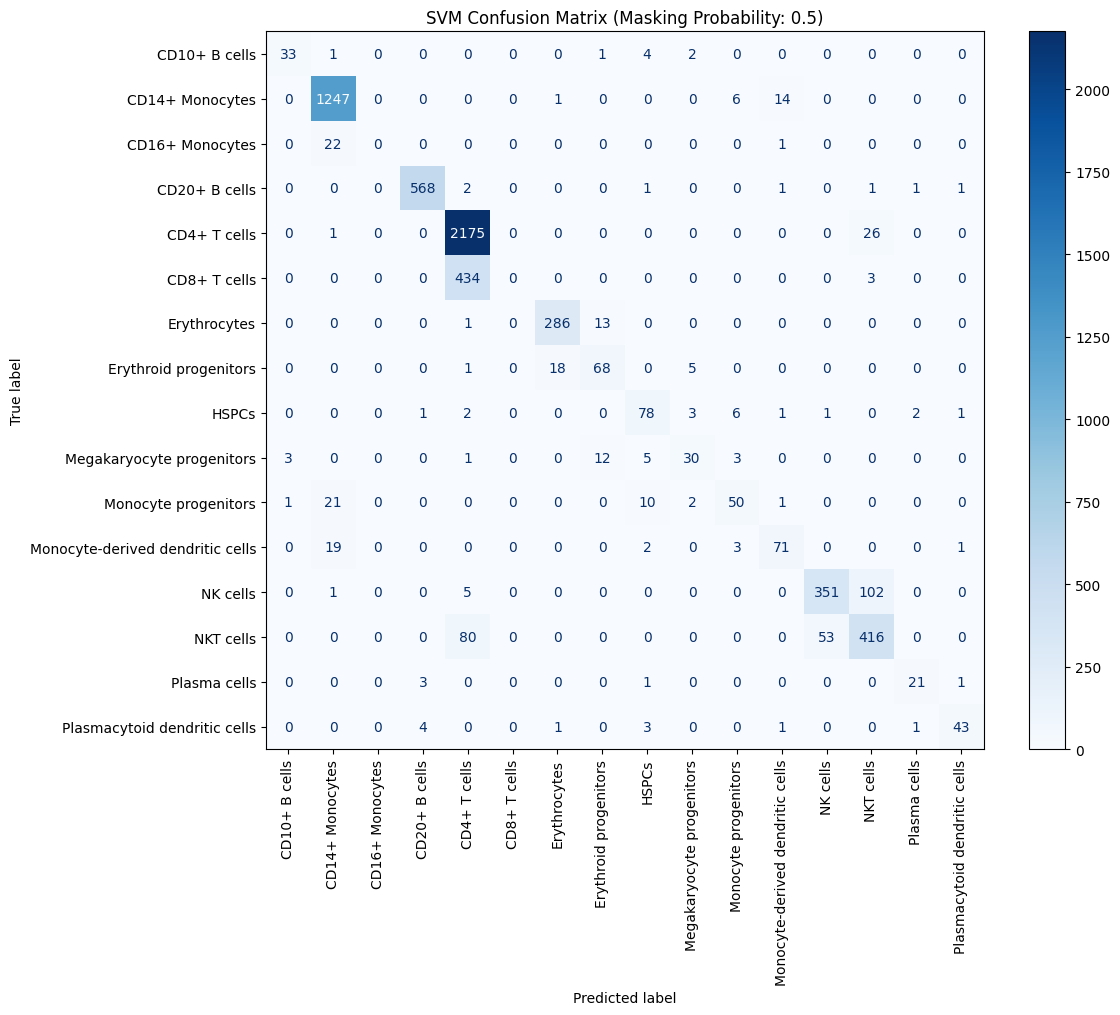

In [6]:
adata_scvi = read_h5ad_file(f"runs/imputation_scvi/mask_50/imputation.h5ad")
with open(f"runs/imputation_scvi/mask_50/predictions.pkl", "rb") as f:
                predictions_scvi = pickle.load(f)

# Extract features (latent representation) and labels
X = predictions_scvi[f"mask50_latent_masked"]
y = adata_scvi.obs["final_annotation"]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the classifiers
lr_model, rf_model, svm_model = train_classifiers(X_train=X_train, y_train=y_train)
        
# Evaluate the classifiers
metrics_df = evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=0.5, noise2self_ratio=0)

In [7]:
# find counts per cell type 
from cellarium.ml.data import read_h5ad_file

adata = read_h5ad_file(f"runs/imputation_0.99/mask_50/imputation.h5ad")
print(adata)
# with open(f"runs/imputation_0.99/mask_{int(prob*100)}/predictions.pkl", "rb") as f:
#     predictions = pickle.load(f)

# # Extract features (latent representation) and labels
# cell_annotation = adata.obs["final_annotation"]

cell_counts = (
    adata.obs["final_annotation"]
    .value_counts()
    .rename("n_cells")
    .reset_index()
    .rename(columns={"index": "cell_type"})
)

print(cell_counts)

AnnData object with n_obs × n_vars = 31774 × 4000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'condition', 'concat'
                    final_annotation  n_cells
0                       CD4+ T cells    11011
1                    CD14+ Monocytes     6338
2                      CD20+ B cells     2873
3                          NKT cells     2745
4                           NK cells     2294
5                       CD8+ T cells     2183
6                       Erythrocytes     1502
7   Monocyte-derived dendritic cells      478
8                              HSPCs      473
9              Erythroid progenitors      463
10              Monocyte progenitors      428
11         Megakaryocyte progenitors      270
12      Plasmacytoid dendritic cells      265
13                     CD10+ B cells      207
14                      Plasma cells      129
15               

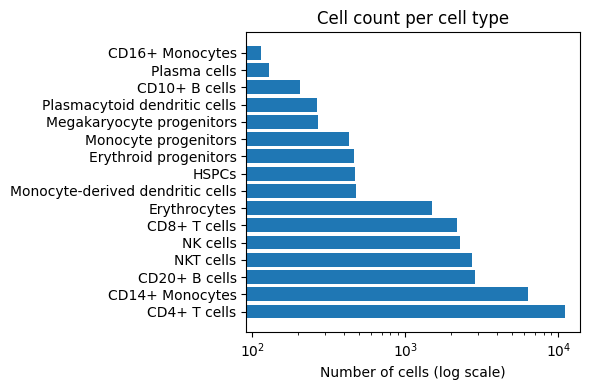

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.barh(
    cell_counts["final_annotation"],
    cell_counts["n_cells"]
)
plt.xscale("log")
plt.xlabel("Number of cells (log scale)")
plt.title("Cell count per cell type")
plt.tight_layout()
plt.show()

In [ ]:
from scipy import sparse
import numpy as np
import pandas as pd

def count_highly_expressed_genes(
    adata,
    cell_type_col="final_annotation",
    min_frac=0.3, # a gene must be expressed in at least 30% of cells to be counted
    min_mean=1.0 # a gene must have a mean expression of at least 1.0 to be counted
):
    results = []

    X = adata.X
    is_sparse = sparse.issparse(X)

    for ct in adata.obs[cell_type_col].unique():
        idx = (adata.obs[cell_type_col] == ct).to_numpy()
        sub = X[idx]

        if is_sparse:
            # fraction of cells expressing gene
            frac_expr = (sub > 0).mean(axis=0).A1
            mean_expr = sub.mean(axis=0).A1
        else:
            frac_expr = (sub > 0).mean(axis=0)
            mean_expr = sub.mean(axis=0)

        n_genes = np.sum(
            (frac_expr >= min_frac) &
            (mean_expr >= min_mean)
        )

        results.append({
            "cell_type": ct,
            "n_high_expr_genes": int(n_genes),
            "n_cells": idx.sum()
        })

    return pd.DataFrame(results)

gene_signal = count_highly_expressed_genes(adata)
print(gene_signal)

                           cell_type  n_high_expr_genes  n_cells
0                       CD4+ T cells                 41    11011
1                    CD14+ Monocytes                339     6338
2                          NKT cells                 78     2745
3                              HSPCs                232      473
4                       CD8+ T cells                 32     2183
5                       Erythrocytes                151     1502
6                      CD10+ B cells                284      207
7       Plasmacytoid dendritic cells                270      265
8               Monocyte progenitors                197      428
9                      CD20+ B cells                 68     2873
10  Monocyte-derived dendritic cells                497      478
11                      Plasma cells                265      129
12             Erythroid progenitors                532      463
13         Megakaryocyte progenitors                386      270
14                       

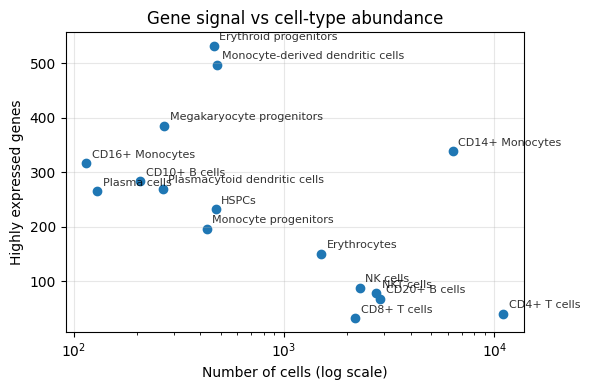

In [17]:
plt.figure(figsize=(6, 4))
plt.scatter(
    gene_signal["n_cells"],
    gene_signal["n_high_expr_genes"]
)

for _, row in gene_signal.iterrows():
    plt.annotate(
        row["cell_type"],
        (row["n_cells"], row["n_high_expr_genes"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.8
    )

plt.xscale("log")
plt.xlabel("Number of cells (log scale)")
plt.ylabel("Highly expressed genes")
plt.title("Gene signal vs cell-type abundance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
